In [1]:
import netCDF4 as nc
import os

#base = "/Users/bernardnkrumahattobrah/Documents/HydroBlocks/data/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_Bernard"
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
cid = 1

input_file = os.path.join(path_pp, f"{cid}/input_file.nc")
output_file = os.path.join(path_pp, f"output_data/{cid}/2016-01-01.nc")

def list_nc_vars(path):
    print(f"\n--- File: {path} ---")
    with nc.Dataset(path) as ds:
        for gname, grp in ds.groups.items():
            print(f"\n[Group: {gname}]")
            for vname, var in grp.variables.items():
                print(f"  {vname:20s} shape={var.shape} dims={var.dimensions}")

# Inspect static (parameters/meteorology)
list_nc_vars(input_file)

# Inspect dynamic outputs
list_nc_vars(output_file)



--- File: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/1/input_file.nc ---

[Group: meteorology]
  lwdown               shape=(8744, 1000) dims=('time', 'hru')
  swdown               shape=(8744, 1000) dims=('time', 'hru')
  tair                 shape=(8744, 1000) dims=('time', 'hru')
  precip               shape=(8744, 1000) dims=('time', 'hru')
  psurf                shape=(8744, 1000) dims=('time', 'hru')
  wind                 shape=(8744, 1000) dims=('time', 'hru')
  spfh                 shape=(8744, 1000) dims=('time', 'hru')
  time                 shape=(8744,) dims=('time',)

[Group: water_use]

[Group: metadata]

[Group: wmatrix_Basin1]
  data                 shape=(4,) dims=('connections_columns',)
  indices              shape=(4,) dims=('connections_columns',)
  indptr               shape=(3,) dims=('connections_rows',)

[Group: wmatrix_Basin2]
  data                 shape=(4,) dims=('connections_c

In [2]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as colors

path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
path_3d = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/"

path = path_3d

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Polar_Plots"
os.makedirs(outputdir, exist_ok=True)

buffer = 250

with nc.Dataset(path + "1/input_file.nc") as fp:
    time = fp.groups["meteorology"]["time"][:]

start = pd.Timestamp("2016-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")

times = pd.Series(datetime_series, name="datetime")
months = np.array(times.dt.month)

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]

    return out

import numpy as np
import netCDF4 as nc
import numba
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os, re, glob
import matplotlib.colors as colors
from pathlib import Path

# model outputs
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
path_3d = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/"

# Path to run
path = path_3d

# output directory
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Polar_Plots"
os.makedirs(outputdir, exist_ok=True)

# READ TIME (FROM INPUT FILE)
fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]
fp.close()

# BUILD DATETIME VECTOR
start = pd.Timestamp("2016-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# Read HRU grid + metadata
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

with rasterio.open(path + "postprocess/cids.vrt") as ds:
    cids = ds.read(1)

with nc.Dataset(path + "output_data/1/2016-01-01.nc") as ds:
    nhrus = ds.groups["data"].variables["totsmc"].shape[1]

def read_grid(fp):
    with rasterio.open(fp) as ds:
        arr = ds.read(1)
        nod = ds.nodata
        if nod is not None:
            arr[arr == nod] = np.nan
        arr[arr == -9999.0] = np.nan
        return arr

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out

def crop_grid(arr, buffer):
    nrows, ncols = arr.shape
    return arr[buffer:nrows-buffer+1, buffer:ncols-buffer+1]


def load_mapping_and_terrain(path_pp, path_3d, buffer):
    hrus_3d = gdal_tools.read_raster(path_3d + "postprocess/hrus.vrt")
    cids_3d = gdal_tools.read_raster(path_3d + "postprocess/cids.vrt")

    hrus_pp = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
    cids_pp = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

    tmp_3d = np.copy(hrus_3d)
    tmp_3d[:] = -9999.0

    tmp_pp = np.copy(hrus_pp)
    tmp_pp[:] = -9999.0

    slope_grid = gdal_tools.read_raster(path_3d + "1/slope_latlon.tif")
    aspect_grid = gdal_tools.read_raster(path_3d + "1/aspect_latlon.tif")

    slope_grid = np.where(slope_grid == -9999, np.nan, slope_grid)
    aspect_grid = np.where(aspect_grid == -9999, np.nan, aspect_grid)

    slope_deg_grid = np.degrees(np.arctan(slope_grid))
    #aspect_deg_grid = np.mod(np.degrees(aspect_grid), 360.0)

    aspect_deg_grid = np.degrees(aspect_grid)
    aspect_deg_grid = np.where(np.isfinite(aspect_deg_grid), np.mod(aspect_deg_grid, 360.0), np.nan)        # solves warning issue if aspect has NaN

    slope_deg_grid = crop_grid(slope_deg_grid, buffer)
    aspect_deg_grid = crop_grid(aspect_deg_grid, buffer)

    print("same HRU grid:", np.array_equal(hrus_3d, hrus_pp))
    print("same CID grid:", np.array_equal(cids_3d, cids_pp))

    return hrus_3d, cids_3d, tmp_3d, hrus_pp, cids_pp, tmp_pp, slope_deg_grid, aspect_deg_grid


def read_hru_vars(path, varnames):
    with nc.Dataset(path + "output_data/1/2016-01-01.nc") as ds:
        grp = ds.groups["data"]
        print("Variables:", list(grp.variables.keys()))

        data = {}
        for var in varnames:
            if var not in grp.variables:
                raise KeyError(f"{var} not found in output")
            data[var] = np.array(grp.variables[var][:], dtype=float)

    return data


def build_polar_from_grid_diff(
    mean_3d, mean_pp,
    hrus_3d, cids_3d, tmp_3d,
    hrus_pp, cids_pp, tmp_pp,
    slope_deg_grid, aspect_deg_grid,
    slope_edges, aspect_edges,
    buffer
):
    grid_3d = place_data(tmp_3d, mean_3d, hrus_3d, cids_3d, 1)
    grid_pp = place_data(tmp_pp, mean_pp, hrus_pp, cids_pp, 1)

    grid_3d = np.where(grid_3d == -9999, np.nan, grid_3d)
    grid_pp = np.where(grid_pp == -9999, np.nan, grid_pp)

    grid_3d = crop_grid(grid_3d, buffer)
    grid_pp = crop_grid(grid_pp, buffer)

    diff_grid = grid_3d - grid_pp

    n_r = len(slope_edges) - 1
    n_t = len(aspect_edges)

    polar_mean = np.full((n_r, n_t), np.nan)
    polar_count = np.zeros((n_r, n_t), dtype=int)

    valid = (
        np.isfinite(diff_grid) &
        np.isfinite(slope_deg_grid) &
        np.isfinite(aspect_deg_grid)
    )

    dvals = diff_grid[valid]
    svals = slope_deg_grid[valid]
    avals = aspect_deg_grid[valid]

    for i in range(n_r):
        s0, s1 = slope_edges[i], slope_edges[i + 1]
        slope_mask = (svals >= s0) & (svals < s1)

        for j in range(n_t):
            a0 = aspect_edges[j]
            a1 = a0 + 22.5

            if a1 < 360:
                aspect_mask = (avals >= a0) & (avals < a1)
            else:
                aspect_mask = (avals >= a0) | (avals < (a1 - 360))

            mask = slope_mask & aspect_mask

            if np.any(mask):
                polar_mean[i, j] = np.nanmean(dvals[mask])
                polar_count[i, j] = np.sum(mask)

    polar_mean = np.column_stack([polar_mean, polar_mean[:, 0]])
    polar_count = np.column_stack([polar_count, polar_count[:, 0]])

    return polar_mean, polar_count

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/729150838.py:141: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.where(np.isfinite(aspect_deg_grid), np.mod(aspect_deg_grid, 360.0), np.nan)        # solves warning issue if aspect has NaN


same HRU grid: False
same CID grid: True
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swdn_3d', 'swnet', 'lwdn', 'lwdn_3d', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swnet', 'lwdn', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/3436431590.py:143: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/3436431590.py:135: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(


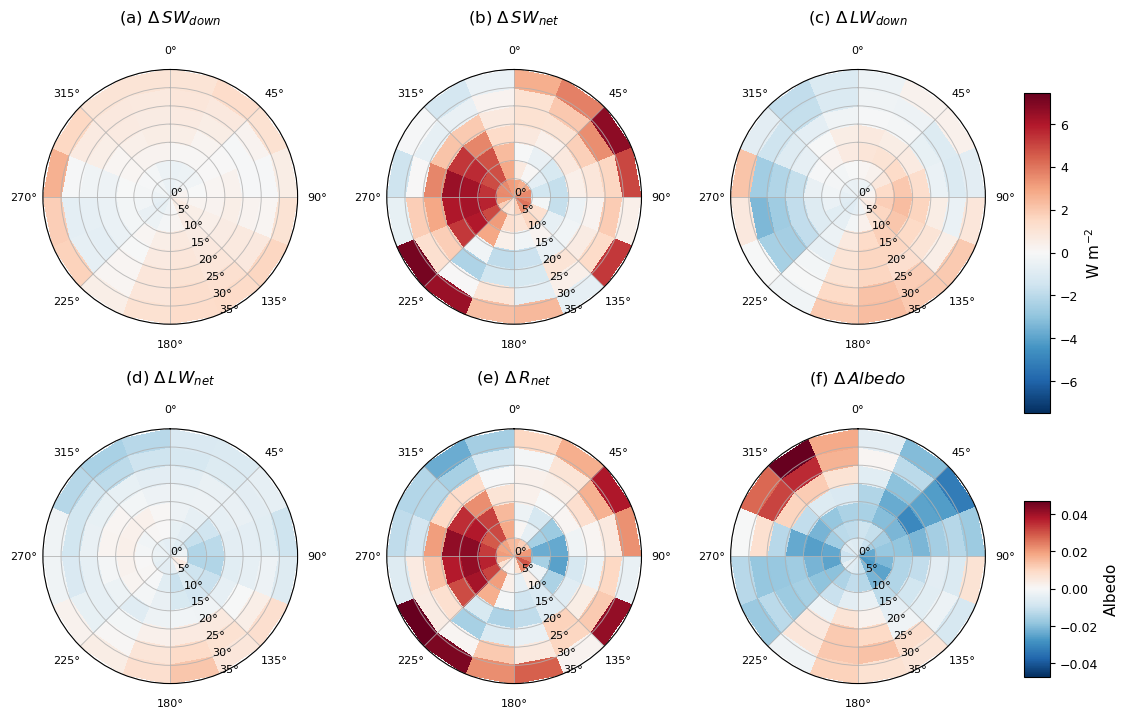

In [3]:
# Polar plots of annual radiation + albedo differences
# Difference = 3D - PP

print("3D:", path_3d)
print("PP:", path_pp)

hrus_3d, cids_3d, tmp_3d, hrus_pp, cids_pp, tmp_pp, slope_deg_grid, aspect_deg_grid = load_mapping_and_terrain(
    path_pp, path_3d, buffer
)

vars_needed = ["swdn", "swnet", "lwdn", "lwnet", "salb"]

data_3d = read_hru_vars(path_3d, vars_needed)
data_pp = read_hru_vars(path_pp, vars_needed)

swdn_3d  = data_3d["swdn"]
swnet_3d = data_3d["swnet"]
lwdn_3d  = data_3d["lwdn"]
lwnet_3d = data_3d["lwnet"]
salb_3d  = data_3d["salb"]

swdn_pp  = data_pp["swdn"]
swnet_pp = data_pp["swnet"]
lwdn_pp  = data_pp["lwdn"]
lwnet_pp = data_pp["lwnet"]
salb_pp  = data_pp["salb"]

# clean albedo
salb_3d = np.where((salb_3d >= 0.0) & (salb_3d <= 1.0), salb_3d, np.nan)
salb_pp = np.where((salb_pp >= 0.0) & (salb_pp <= 1.0), salb_pp, np.nan)

# net radiation
rnet_3d = swnet_3d + lwnet_3d
rnet_pp = swnet_pp + lwnet_pp

mean_3d = {
    "ΔSWdown": np.nanmean(swdn_3d,  axis=0),
    "ΔSWnet":  np.nanmean(swnet_3d, axis=0),
    "ΔLWdown": np.nanmean(lwdn_3d,  axis=0),
    "ΔLWnet":  np.nanmean(lwnet_3d, axis=0),
    "ΔRnet":   np.nanmean(rnet_3d,  axis=0),
    "ΔAlbedo": np.nanmean(salb_3d,  axis=0),
}

mean_pp = {
    "ΔSWdown": np.nanmean(swdn_pp,  axis=0),
    "ΔSWnet":  np.nanmean(swnet_pp, axis=0),
    "ΔLWdown": np.nanmean(lwdn_pp,  axis=0),
    "ΔLWnet":  np.nanmean(lwnet_pp, axis=0),
    "ΔRnet":   np.nanmean(rnet_pp,  axis=0),
    "ΔAlbedo": np.nanmean(salb_pp,  axis=0),
}

# slope/aspect bins
slope_edges = np.arange(0, 40, 5)
aspect_edges = np.arange(0, 360, 22.5)

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
Theta, R = np.meshgrid(theta_edges, slope_edges)

panel_order = ["ΔSWdown", "ΔSWnet", "ΔLWdown", "ΔLWnet", "ΔRnet", "ΔAlbedo"]

polar_means = {}
polar_counts = {}

for key in panel_order:
    pm, pc = build_polar_from_grid_diff(
        mean_3d[key], mean_pp[key],
        hrus_3d, cids_3d, tmp_3d,
        hrus_pp, cids_pp, tmp_pp,
        slope_deg_grid, aspect_deg_grid,
        slope_edges, aspect_edges,
        buffer
    )

    polar_means[key] = pm
    polar_counts[key] = pc

# color scales
rad_keys = ["ΔSWdown", "ΔSWnet", "ΔLWdown", "ΔLWnet", "ΔRnet"]

all_rad_vals = []
for key in rad_keys:
    vals = polar_means[key]
    vals = vals[np.isfinite(vals)]
    if vals.size > 0:
        all_rad_vals.append(vals)

all_rad_vals = np.concatenate(all_rad_vals)
vmax_rad = np.nanmax(np.abs(all_rad_vals))

if not np.isfinite(vmax_rad) or vmax_rad == 0:
    vmax_rad = 1.0

alb_vals = polar_means["ΔAlbedo"]
alb_vals = alb_vals[np.isfinite(alb_vals)]
vmax_alb = np.nanmax(np.abs(alb_vals))

if not np.isfinite(vmax_alb) or vmax_alb == 0:
    vmax_alb = 0.01

norm_rad = colors.TwoSlopeNorm(vmin=-vmax_rad, vcenter=0.0, vmax=vmax_rad)
norm_alb = colors.TwoSlopeNorm(vmin=-vmax_alb, vcenter=0.0, vmax=vmax_alb)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

# plot
fig = plt.figure(figsize=(13, 8), facecolor="white")

axes = [
    fig.add_subplot(2, 3, 1, projection="polar"),
    fig.add_subplot(2, 3, 2, projection="polar"),
    fig.add_subplot(2, 3, 3, projection="polar"),
    fig.add_subplot(2, 3, 4, projection="polar"),
    fig.add_subplot(2, 3, 5, projection="polar"),
    fig.add_subplot(2, 3, 6, projection="polar"),
]

panel_titles = [
    r"(a) $\Delta\,SW_{down}$",
    r"(b) $\Delta\,SW_{net}$",
    r"(c) $\Delta\,LW_{down}$",
    r"(d) $\Delta\,LW_{net}$",
    r"(e) $\Delta\,R_{net}$",
    r"(f) $\Delta\,Albedo$",
]

pcm_rad = None
pcm_alb = None

for ax, key, title in zip(axes, panel_order, panel_titles):

    if key == "ΔAlbedo":
        pcm = ax.pcolormesh(
            Theta, R, polar_means[key],
            cmap=cmap,
            norm=norm_alb,
            shading="auto"
        )
        pcm_alb = pcm
    else:
        pcm = ax.pcolormesh(
            Theta, R, polar_means[key],
            cmap=cmap,
            norm=norm_rad,
            shading="auto"
        )
        pcm_rad = pcm

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 35)
    ax.set_rticks(np.arange(0, 36, 5))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 36, 5)], fontsize=8)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(
        np.arange(0, 360, 45),
        labels=[f"{a}°" for a in np.arange(0, 360, 45)],
        fontsize=8
    )

    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.set_title(title, fontsize=12, pad=16)
    ax.set_facecolor("white")

plt.subplots_adjust(wspace=0.35, hspace=0.40, right=0.85)

# radiation colorbar
cax1 = fig.add_axes([0.88, 0.45, 0.02, 0.40])
cbar1 = fig.colorbar(pcm_rad, cax=cax1)
cbar1.set_label(r"W m$^{-2}$", fontsize=11)
cbar1.ax.tick_params(labelsize=9)

# albedo colorbar
cax2 = fig.add_axes([0.88, 0.12, 0.02, 0.22])
cbar2 = fig.colorbar(pcm_alb, cax=cax2)
cbar2.set_label("Albedo", fontsize=11)
cbar2.ax.tick_params(labelsize=9)

plt.savefig(
    os.path.join(outputdir, "masked_polar_annual_diff_radiation_albedo_gridspace_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()



Slope range: 0.0 63.863884
Aspect range: 0.0 359.99985


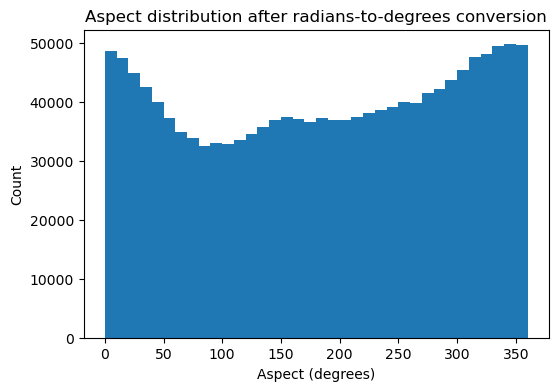


Counts per bin for ΔSWdown:
[[50646 45297 38923 33820 32572 31602 32006 32254 35914 39627 41500 42373
  45538 49280 52653 53771 50646]
 [22817 20299 18573 17238 17555 18650 19413 18539 16633 16521 18989 21117
  22510 23751 24151 23716 22817]
 [13584 12603 11333 10625 10961 11594 12757 11631 11321 11599 12956 13252
  13215 13233 13761 13614 13584]
 [ 9377  8846  7666  7160  7220  7796  8994  9092  8662  7877  7973  7672
   7977  8697  9342  9617  9377]
 [ 6216  5363  4482  4057  3886  4558  5836  6316  6173  5107  4037  3637
   3754  4405  5622  6422  6216]
 [ 3023  2443  1603  1289  1391  1947  2871  3554  3219  2319  1368  1063
    919  1359  2196  2955  3023]
 [  746   511   330   274   346   473   964  1214  1055   608   241   148
    129   253   580   777   746]]

Counts per bin for ΔSWnet:
[[50646 45297 38923 33820 32572 31602 32006 32254 35914 39627 41500 42373
  45538 49280 52653 53771 50646]
 [22817 20299 18573 17238 17555 18650 19413 18539 16633 16521 18989 21117
  22510 2375

In [4]:
# diagnostics
print("Slope range:", np.nanmin(slope_deg_grid), np.nanmax(slope_deg_grid))
print("Aspect range:", np.nanmin(aspect_deg_grid), np.nanmax(aspect_deg_grid))

plt.figure(figsize=(6, 4))
plt.hist(aspect_deg_grid[np.isfinite(aspect_deg_grid)].flatten(), bins=36)
plt.title("Aspect distribution after radians-to-degrees conversion")
plt.xlabel("Aspect (degrees)")
plt.ylabel("Count")
plt.show()

for key in panel_order:
    print(f"\nCounts per bin for {key}:")
    print(polar_counts[key])

In [5]:
threshold = 200

for key in panel_order:
    print(f"\nLow-count bins for {key} (<{threshold} cells):")

    pc = polar_counts[key][:, :-1]   # remove duplicated last column

    for i in range(pc.shape[0]):       # slope bins
        for j in range(pc.shape[1]):   # aspect bins
            if pc[i, j] < threshold:
                
                s0 = slope_edges[i]
                s1 = slope_edges[i+1]

                a0 = aspect_edges[j]
                a1 = a0 + 22.5

                print(f"  Slope {s0:>2}-{s1:<2}°, Aspect {a0:>5.1f}-{a1:<5.1f}°, Count={pc[i,j]}")


Low-count bins for ΔSWdown (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129

Low-count bins for ΔSWnet (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129

Low-count bins for ΔLWdown (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129

Low-count bins for ΔLWnet (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129

Low-count bins for ΔRnet (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129

Low-count bins for ΔAlbedo (<200 cells):
  Slope 30-35°, Aspect 247.5-270.0°, Count=148
  Slope 30-35°, Aspect 270.0-292.5°, Count=129


In [6]:
threshold = 200

for key in panel_order:
    pc = polar_counts[key][:, :-1]

    total_bins = pc.size
    low_bins = np.sum(pc < threshold)

    print(f"\n{key}:")
    print(f"  Total bins: {total_bins}")
    print(f"  Bins < {threshold}: {low_bins} ({100*low_bins/total_bins:.2f}%)")


ΔSWdown:
  Total bins: 112
  Bins < 200: 2 (1.79%)

ΔSWnet:
  Total bins: 112
  Bins < 200: 2 (1.79%)

ΔLWdown:
  Total bins: 112
  Bins < 200: 2 (1.79%)

ΔLWnet:
  Total bins: 112
  Bins < 200: 2 (1.79%)

ΔRnet:
  Total bins: 112
  Bins < 200: 2 (1.79%)

ΔAlbedo:
  Total bins: 112
  Bins < 200: 2 (1.79%)


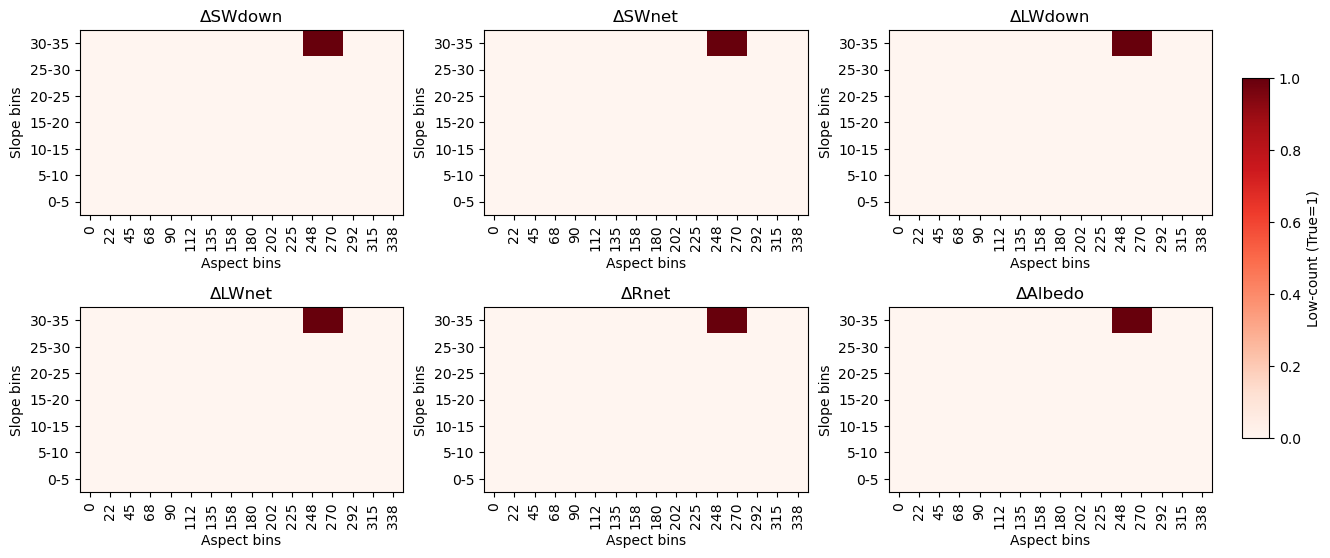

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()

for i, key in enumerate(panel_order):
    ax = axes[i]

    pc = polar_counts[key][:, :-1]
    low_mask = pc < 200

    im = ax.imshow(low_mask, cmap="Reds", origin="lower", aspect="auto")

    ax.set_title(f"{key}")
    ax.set_xlabel("Aspect bins")
    ax.set_ylabel("Slope bins")

    ax.set_xticks(range(len(aspect_edges)))
    ax.set_xticklabels([f"{a:.0f}" for a in aspect_edges], rotation=90)

    ax.set_yticks(range(len(slope_edges)-1))
    ax.set_yticklabels([f"{slope_edges[i]}-{slope_edges[i+1]}" for i in range(len(slope_edges)-1)])

# manually tighten panels and leave room for colorbar
plt.subplots_adjust(hspace=0.50, wspace=0.25, right=0.88)

# colorbar outside right
cbar_ax = fig.add_axes([0.90, 0.20, 0.018, 0.60])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Low-count (True=1)")

plt.show()

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/729150838.py:141: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.where(np.isfinite(aspect_deg_grid), np.mod(aspect_deg_grid, 360.0), np.nan)        # solves warning issue if aspect has NaN


same HRU grid: False
same CID grid: True
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swdn_3d', 'swnet', 'lwdn', 'lwdn_3d', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swnet', 'lwdn', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/3361920871.py:110: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(Theta, R, polar_means[key],
/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/3361920871.py:106: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(Theta, R, polar_means[key],


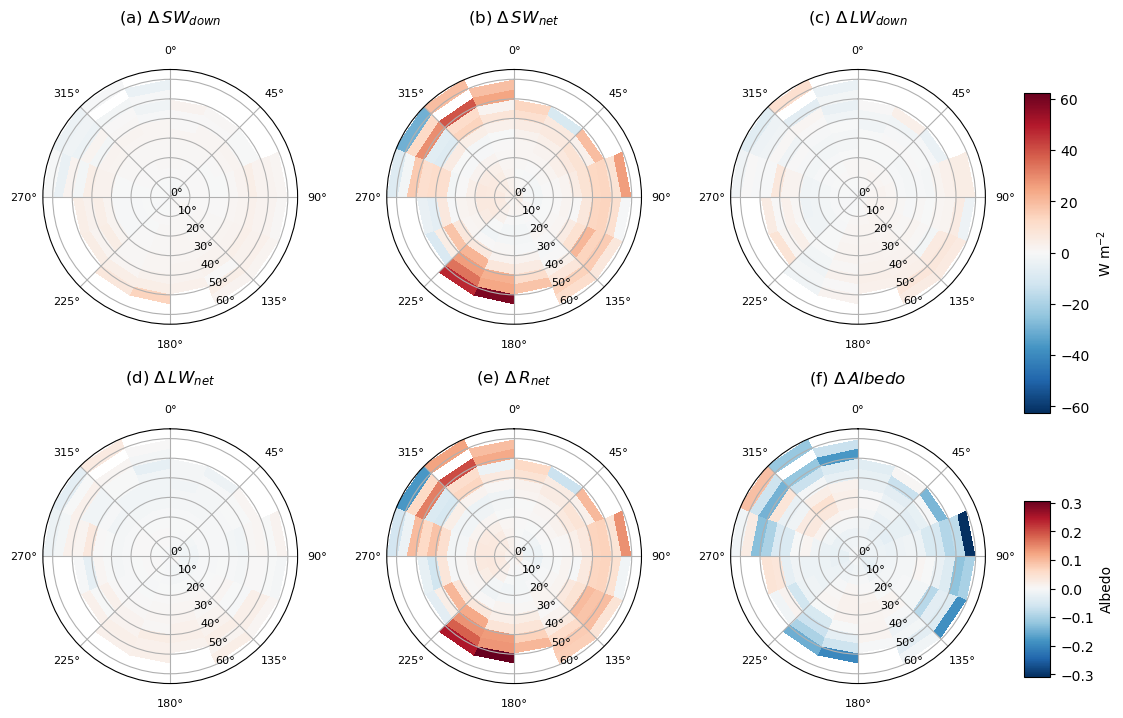

In [8]:
print("3D:", path_3d)
print("PP:", path_pp)

# use function instead of manual mapping block
hrus_3d, cids_3d, tmp_3d, hrus_pp, cids_pp, tmp_pp, slope_deg_grid, aspect_deg_grid = \
    load_mapping_and_terrain(path_pp, path_3d, buffer)

# read variables using function
vars_3d = read_hru_vars(path_3d, ["swdn", "swnet", "lwdn", "lwnet", "salb"])
vars_pp = read_hru_vars(path_pp, ["swdn", "swnet", "lwdn", "lwnet", "salb"])

# clean albedo
vars_3d["salb"] = np.where((vars_3d["salb"] >= 0.0) & (vars_3d["salb"] <= 1.0), vars_3d["salb"], np.nan)
vars_pp["salb"] = np.where((vars_pp["salb"] >= 0.0) & (vars_pp["salb"] <= 1.0), vars_pp["salb"], np.nan)

# compute net radiation
vars_3d["rnet"] = vars_3d["swnet"] + vars_3d["lwnet"]
vars_pp["rnet"] = vars_pp["swnet"] + vars_pp["lwnet"]

# HRU means
mean_3d = {
    "ΔSWdown": np.nanmean(vars_3d["swdn"], axis=0),
    "ΔSWnet":  np.nanmean(vars_3d["swnet"], axis=0),
    "ΔLWdown": np.nanmean(vars_3d["lwdn"], axis=0),
    "ΔLWnet":  np.nanmean(vars_3d["lwnet"], axis=0),
    "ΔRnet":   np.nanmean(vars_3d["rnet"], axis=0),
    "ΔAlbedo": np.nanmean(vars_3d["salb"], axis=0),
}

mean_pp = {
    "ΔSWdown": np.nanmean(vars_pp["swdn"], axis=0),
    "ΔSWnet":  np.nanmean(vars_pp["swnet"], axis=0),
    "ΔLWdown": np.nanmean(vars_pp["lwdn"], axis=0),
    "ΔLWnet":  np.nanmean(vars_pp["lwnet"], axis=0),
    "ΔRnet":   np.nanmean(vars_pp["rnet"], axis=0),
    "ΔAlbedo": np.nanmean(vars_pp["salb"], axis=0),
}

# bins
slope_edges = np.arange(0, 70, 5)
aspect_edges = np.arange(0, 360, 22.5)

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
r_edges = slope_edges
Theta, R = np.meshgrid(theta_edges, r_edges)

# build polar using your function
panel_order = ["ΔSWdown", "ΔSWnet", "ΔLWdown", "ΔLWnet", "ΔRnet", "ΔAlbedo"]

polar_means = {}
polar_counts = {}

for key in panel_order:
    pm, pc = build_polar_from_grid_diff(
        mean_3d[key], mean_pp[key],
        hrus_3d, cids_3d, tmp_3d,
        hrus_pp, cids_pp, tmp_pp,
        slope_deg_grid, aspect_deg_grid,
        slope_edges, aspect_edges,
        buffer
    )
    polar_means[key] = pm
    polar_counts[key] = pc

# color scaling
rad_keys = ["ΔSWdown", "ΔSWnet", "ΔLWdown", "ΔLWnet", "ΔRnet"]

all_rad_vals = np.concatenate([
    polar_means[k][np.isfinite(polar_means[k])] for k in rad_keys
])

vmax_rad = np.nanmax(np.abs(all_rad_vals))
vmax_rad = vmax_rad if np.isfinite(vmax_rad) else 1.0

alb_vals = polar_means["ΔAlbedo"]
alb_vals = alb_vals[np.isfinite(alb_vals)]
vmax_alb = np.nanmax(np.abs(alb_vals))
vmax_alb = vmax_alb if np.isfinite(vmax_alb) else 0.01

norm_rad = colors.TwoSlopeNorm(vmin=-vmax_rad, vcenter=0, vmax=vmax_rad)
norm_alb = colors.TwoSlopeNorm(vmin=-vmax_alb, vcenter=0, vmax=vmax_alb)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

# plotting
fig = plt.figure(figsize=(13, 8), facecolor="white")

axes = [fig.add_subplot(2,3,i+1, projection="polar") for i in range(6)]

titles = [
    r"(a) $\Delta\,SW_{down}$",
    r"(b) $\Delta\,SW_{net}$",
    r"(c) $\Delta\,LW_{down}$",
    r"(d) $\Delta\,LW_{net}$",
    r"(e) $\Delta\,R_{net}$",
    r"(f) $\Delta\,Albedo$"
]

pcm_rad = None
pcm_alb = None

for ax, key, title in zip(axes, panel_order, titles):

    if key == "ΔAlbedo":
        pcm = ax.pcolormesh(Theta, R, polar_means[key],
                            cmap=cmap, norm=norm_alb, shading="auto")
        pcm_alb = pcm
    else:
        pcm = ax.pcolormesh(Theta, R, polar_means[key],
                            cmap=cmap, norm=norm_rad, shading="auto")
        pcm_rad = pcm

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 65)
    ax.set_rticks(np.arange(0, 66, 10))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 66, 10)], fontsize=8)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(np.arange(0,360,45),
                      labels=[f"{a}°" for a in np.arange(0,360,45)],
                      fontsize=8)

    ax.set_title(title, fontsize=12, pad=16)
    ax.grid(True)

plt.subplots_adjust(wspace=0.35, hspace=0.40, right=0.85)

# colorbars
cax1 = fig.add_axes([0.88, 0.45, 0.02, 0.40])
fig.colorbar(pcm_rad, cax=cax1).set_label(r"W m$^{-2}$")

cax2 = fig.add_axes([0.88, 0.12, 0.02, 0.22])
fig.colorbar(pcm_alb, cax=cax2).set_label("Albedo")

plt.savefig(
    os.path.join(outputdir, "full_polar_annual_diff_radiation_albedo_gridspace_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/729150838.py:141: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.where(np.isfinite(aspect_deg_grid), np.mod(aspect_deg_grid, 360.0), np.nan)        # solves warning issue if aspect has NaN


same HRU grid: False
same CID grid: True
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swdn_3d', 'swnet', 'lwdn', 'lwdn_3d', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swnet', 'lwdn', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/3804367929.py:90: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(


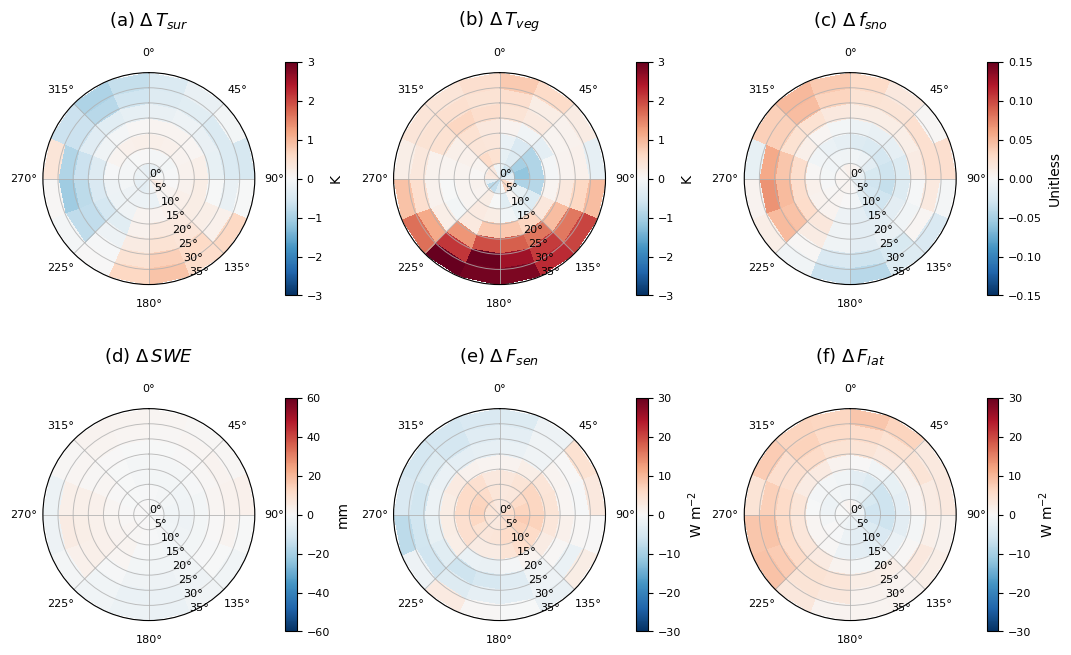

Slope range: 0.0 63.863884
Aspect range: 0.0 359.99985
ΔTsur: polar min=-1.0553, max=0.8656, mean=-0.0981

Counts per bin for ΔTsur:
[[50646 45297 38923 33820 32572 31602 32006 32254 35914 39627 41500 42373
  45538 49280 52653 53771 50646]
 [22817 20299 18573 17238 17555 18650 19413 18539 16633 16521 18989 21117
  22510 23751 24151 23716 22817]
 [13584 12603 11333 10625 10961 11594 12757 11631 11321 11599 12956 13252
  13215 13233 13761 13614 13584]
 [ 9377  8846  7666  7160  7220  7796  8994  9092  8662  7877  7973  7672
   7977  8697  9342  9617  9377]
 [ 6216  5363  4482  4057  3886  4558  5836  6316  6173  5107  4037  3637
   3754  4405  5622  6422  6216]
 [ 3023  2443  1603  1289  1391  1947  2871  3554  3219  2319  1368  1063
    919  1359  2196  2955  3023]
 [  746   511   330   274   346   473   964  1214  1055   608   241   148
    129   253   580   777   746]]
ΔTveg: polar min=-1.1895, max=3.1028, mean=0.3703

Counts per bin for ΔTveg:
[[50646 45297 38923 33820 32572 31602 32

In [9]:
print("3D:", path_3d)
print("PP:", path_pp)

hrus_3d, cids_3d, tmp_3d, hrus_pp, cids_pp, tmp_pp, slope_deg_grid, aspect_deg_grid = \
    load_mapping_and_terrain(path_pp, path_3d, buffer)

vars_3d = read_hru_vars(path_3d, ["tv", "trad", "sh", "lh", "fsno", "swe"])
vars_pp = read_hru_vars(path_pp, ["tv", "trad", "sh", "lh", "fsno", "swe"])

mean_3d = {
    "ΔTveg": np.nanmean(vars_3d["tv"], axis=0),
    "ΔTsur": np.nanmean(vars_3d["trad"], axis=0),
    "ΔFsen": np.nanmean(vars_3d["sh"], axis=0),
    "ΔFlat": np.nanmean(vars_3d["lh"], axis=0),
    "Δfsno": np.nanmean(vars_3d["fsno"], axis=0),
    "ΔSWE":  np.nanmean(vars_3d["swe"], axis=0),
}

mean_pp = {
    "ΔTveg": np.nanmean(vars_pp["tv"], axis=0),
    "ΔTsur": np.nanmean(vars_pp["trad"], axis=0),
    "ΔFsen": np.nanmean(vars_pp["sh"], axis=0),
    "ΔFlat": np.nanmean(vars_pp["lh"], axis=0),
    "Δfsno": np.nanmean(vars_pp["fsno"], axis=0),
    "ΔSWE":  np.nanmean(vars_pp["swe"], axis=0),
}

slope_edges = np.arange(0, 40, 5)
aspect_edges = np.arange(0, 360, 22.5)

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
Theta, R = np.meshgrid(theta_edges, slope_edges)

panel_build_order = ["ΔTveg", "ΔTsur", "ΔFsen", "ΔFlat", "Δfsno", "ΔSWE"]

polar_means = {}
polar_counts = {}

for key in panel_build_order:
    pm, pc = build_polar_from_grid_diff(
        mean_3d[key], mean_pp[key],
        hrus_3d, cids_3d, tmp_3d,
        hrus_pp, cids_pp, tmp_pp,
        slope_deg_grid, aspect_deg_grid,
        slope_edges, aspect_edges,
        buffer
    )
    polar_means[key] = pm
    polar_counts[key] = pc

norms = {
    "ΔTveg": colors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3),
    "ΔTsur": colors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3),
    "ΔFsen": colors.TwoSlopeNorm(vmin=-30, vcenter=0, vmax=30),
    "ΔFlat": colors.TwoSlopeNorm(vmin=-30, vcenter=0, vmax=30),
    "Δfsno": colors.TwoSlopeNorm(vmin=-0.15, vcenter=0, vmax=0.15),
    "ΔSWE":  colors.TwoSlopeNorm(vmin=-60, vcenter=0, vmax=60),
}

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

fig = plt.figure(figsize=(13, 8), facecolor="white")
axes = [fig.add_subplot(2, 3, i+1, projection="polar") for i in range(6)]

panel_order = ["ΔTsur", "ΔTveg", "Δfsno", "ΔSWE", "ΔFsen", "ΔFlat"]

titles = [
    r"(a) $\Delta\,T_{sur}$",
    r"(b) $\Delta\,T_{veg}$",
    r"(c) $\Delta\,f_{sno}$",
    r"(d) $\Delta\,SWE$",
    r"(e) $\Delta\,F_{sen}$",
    r"(f) $\Delta\,F_{lat}$",
]

units = {
    "ΔTveg": "K",
    "ΔTsur": "K",
    "ΔFsen": r"W m$^{-2}$",
    "ΔFlat": r"W m$^{-2}$",
    "Δfsno": "Unitless",
    "ΔSWE": "mm",
}

pcms = {}

for ax, key, title in zip(axes, panel_order, titles):

    pcm = ax.pcolormesh(
        Theta, R, polar_means[key],
        cmap=cmap,
        norm=norms[key],
        shading="auto"
    )

    pcms[key] = pcm

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 35)
    ax.set_rticks(np.arange(0, 36, 5))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 36, 5)], fontsize=8)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(
        np.arange(0, 360, 45),
        labels=[f"{a}°" for a in np.arange(0, 360, 45)],
        fontsize=8
    )

    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.set_title(title, fontsize=13, pad=16)
    ax.set_facecolor("white")

plt.subplots_adjust(wspace=0.38, hspace=0.20, right=0.86)

for ax, key in zip(axes, panel_order):
    cbar = fig.colorbar(pcms[key], ax=ax, fraction=0.046, pad=0.12)
    cbar.set_label(units[key], fontsize=10)
    cbar.ax.tick_params(labelsize=8)

plt.savefig(
    os.path.join(outputdir, "polar_annual_diff_temp_flux_snow_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Slope range:", np.nanmin(slope_deg_grid), np.nanmax(slope_deg_grid))
print("Aspect range:", np.nanmin(aspect_deg_grid), np.nanmax(aspect_deg_grid))

for key in panel_order:
    vals = polar_means[key]
    vals = vals[np.isfinite(vals)]

    print(f"{key}: polar min={np.nanmin(vals):.4f}, max={np.nanmax(vals):.4f}, mean={np.nanmean(vals):.4f}")
    print(f"\nCounts per bin for {key}:")
    print(polar_counts[key])

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_507314/729150838.py:141: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.where(np.isfinite(aspect_deg_grid), np.mod(aspect_deg_grid, 360.0), np.nan)        # solves warning issue if aspect has NaN


same HRU grid: False
same CID grid: True
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swdn_3d', 'swnet', 'lwdn', 'lwdn_3d', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swnet', 'lwdn', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
Processing: Winter
Processing: Spring
Processing: Summer
Processing: Fall
Processing: Annual


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_507314/1770186253.py:84: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(


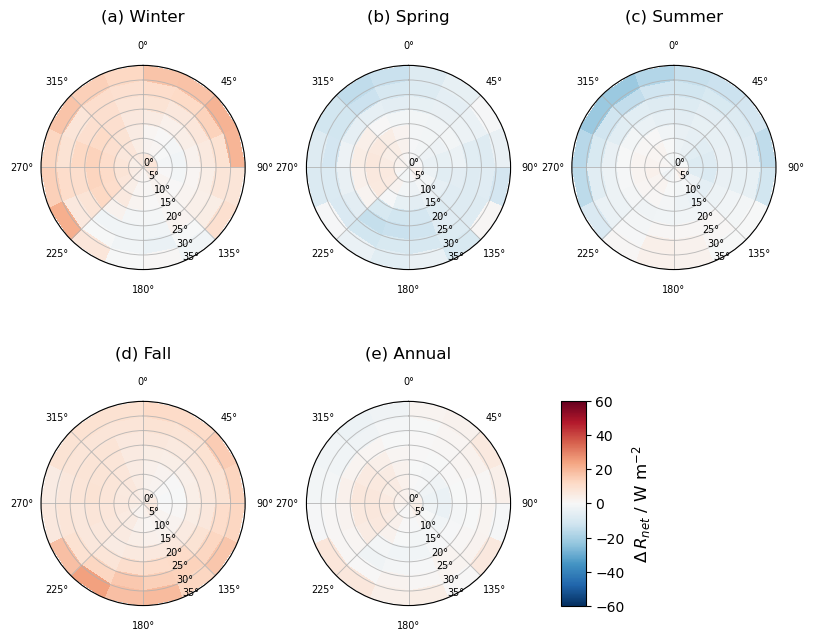

In [3]:
print("3D:", path_3d)
print("PP:", path_pp)

# load mapping + terrain
hrus_3d, cids_3d, tmp_3d, hrus_pp, cids_pp, tmp_pp, slope_deg_grid, aspect_deg_grid = \
    load_mapping_and_terrain(path_pp, path_3d, buffer)

# read variables
vars_3d = read_hru_vars(path_3d, ["swnet", "lwnet"])
vars_pp = read_hru_vars(path_pp, ["swnet", "lwnet"])

rnet_3d = vars_3d["swnet"] + vars_3d["lwnet"]
rnet_pp = vars_pp["swnet"] + vars_pp["lwnet"]

# time → months
months = np.array(times.dt.month)

season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
    "Annual": list(range(1, 13)),
}

# bins
slope_edges = np.arange(0, 40, 5)
aspect_edges = np.arange(0, 360, 22.5)

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
Theta, R = np.meshgrid(theta_edges, slope_edges)

# build seasonal polar
polar_means = {}
polar_counts = {}

for season, mons in season_months.items():

    print("Processing:", season)

    tmask = np.isin(months, mons)

    mean_3d = np.nanmean(rnet_3d[tmask, :], axis=0)
    mean_pp = np.nanmean(rnet_pp[tmask, :], axis=0)

    pm, pc = build_polar_from_grid_diff(
        mean_3d, mean_pp,
        hrus_3d, cids_3d, tmp_3d,
        hrus_pp, cids_pp, tmp_pp,
        slope_deg_grid, aspect_deg_grid,
        slope_edges, aspect_edges,
        buffer
    )

    polar_means[season] = pm
    polar_counts[season] = pc

# plot
fig = plt.figure(figsize=(10, 8), facecolor="white")

positions = [1, 2, 3, 4, 5]
seasons_plot = ["Winter", "Spring", "Summer", "Fall", "Annual"]

titles = [
    r"(a) Winter",
    r"(b) Spring",
    r"(c) Summer",
    r"(d) Fall",
    r"(e) Annual",
]

norm = colors.TwoSlopeNorm(vmin=-60, vcenter=0.0, vmax=60)
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

axes_list = []
pcm = None

for idx, season, title in zip(positions, seasons_plot, titles):

    ax = fig.add_subplot(2, 3, idx, projection="polar")
    axes_list.append(ax)

    pcm = ax.pcolormesh(
        Theta, R, polar_means[season],
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 35)
    ax.set_rticks(np.arange(0, 36, 5))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 36, 5)], fontsize=7)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(
        np.arange(0, 360, 45),
        labels=[f"{a}°" for a in np.arange(0, 360, 45)],
        fontsize=7
    )

    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.set_title(title, fontsize=12, pad=14)

plt.subplots_adjust(wspace=0.30, hspace=0.20, right=0.86)

# colorbar beside Annual
last_ax = axes_list[-1]
bbox = last_ax.get_position()

cax = fig.add_axes([
    bbox.x1 + 0.05,
    bbox.y0,
    0.025,
    bbox.height
])

cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label(r"$\Delta\,R_{net}$ / W m$^{-2}$", fontsize=12)

plt.savefig(
    os.path.join(outputdir, "polar_seasonal_annual_diff_Rnet_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_507314/729150838.py:141: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.where(np.isfinite(aspect_deg_grid), np.mod(aspect_deg_grid, 360.0), np.nan)        # solves warning issue if aspect has NaN


same HRU grid: False
same CID grid: True
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swdn_3d', 'swnet', 'lwdn', 'lwdn_3d', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swnet', 'lwdn', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_507314/2687251761.py:127: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(


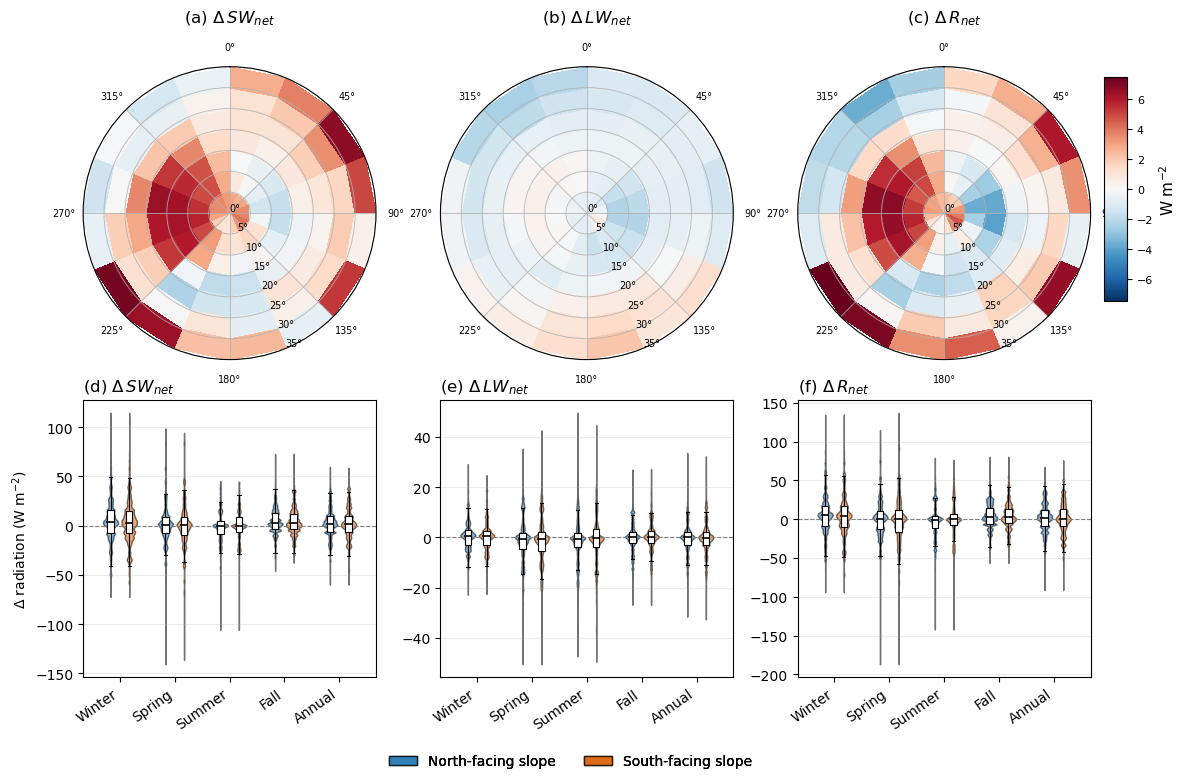

Slope range: 0.0 63.863884
Aspect range: 0.0 359.99985


In [4]:
print("3D:", path_3d)
print("PP:", path_pp)

hrus_3d, cids_3d, tmp_3d, hrus_pp, cids_pp, tmp_pp, slope_deg_grid, aspect_deg_grid = \
    load_mapping_and_terrain(path_pp, path_3d, buffer)

vars_3d = read_hru_vars(path_3d, ["swnet", "lwnet"])
vars_pp = read_hru_vars(path_pp, ["swnet", "lwnet"])

vars_3d["rnet"] = vars_3d["swnet"] + vars_3d["lwnet"]
vars_pp["rnet"] = vars_pp["swnet"] + vars_pp["lwnet"]

var_keys = ["ΔSWnet", "ΔLWnet", "ΔRnet"]

var_map = {
    "ΔSWnet": "swnet",
    "ΔLWnet": "lwnet",
    "ΔRnet": "rnet",
}

slope_edges = np.arange(0, 40, 5)
aspect_edges = np.arange(0, 360, 22.5)

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
Theta, R = np.meshgrid(theta_edges, slope_edges)

polar_means = {}
polar_counts = {}

for key in var_keys:
    v = var_map[key]

    mean_3d = np.nanmean(vars_3d[v], axis=0)
    mean_pp = np.nanmean(vars_pp[v], axis=0)

    pm, pc = build_polar_from_grid_diff(
        mean_3d, mean_pp,
        hrus_3d, cids_3d, tmp_3d,
        hrus_pp, cids_pp, tmp_pp,
        slope_deg_grid, aspect_deg_grid,
        slope_edges, aspect_edges,
        buffer
    )

    polar_means[key] = pm
    polar_counts[key] = pc

def make_diff_grid(mean_3d, mean_pp):
    grid_3d = place_data(tmp_3d, mean_3d, hrus_3d, cids_3d, 1)
    grid_pp = place_data(tmp_pp, mean_pp, hrus_pp, cids_pp, 1)

    grid_3d = np.where(grid_3d == -9999, np.nan, grid_3d)
    grid_pp = np.where(grid_pp == -9999, np.nan, grid_pp)

    grid_3d = crop_grid(grid_3d, buffer)
    grid_pp = crop_grid(grid_pp, buffer)

    return grid_3d - grid_pp

season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall": [9, 10, 11],
    "Annual": list(range(1, 13)),
}

seasons_plot = ["Winter", "Spring", "Summer", "Fall", "Annual"]

north_mask = ((aspect_deg_grid <= 90) | (aspect_deg_grid >= 270))
south_mask = ((aspect_deg_grid > 90) & (aspect_deg_grid < 270))
slope_mask = (slope_deg_grid >= 0) & (slope_deg_grid <= 35)

box_data = {}

for key in var_keys:
    v = var_map[key]
    box_data[key] = {"North": [], "South": []}

    for season in seasons_plot:
        mons = season_months[season]
        tmask = np.isin(months, mons)

        mean_3d = np.nanmean(vars_3d[v][tmask, :], axis=0)
        mean_pp = np.nanmean(vars_pp[v][tmask, :], axis=0)

        diff_grid = make_diff_grid(mean_3d, mean_pp)

        valid = np.isfinite(diff_grid) & np.isfinite(aspect_deg_grid) & np.isfinite(slope_deg_grid) & slope_mask

        north_vals = diff_grid[valid & north_mask]
        south_vals = diff_grid[valid & south_mask]

        box_data[key]["North"].append(north_vals)
        box_data[key]["South"].append(south_vals)

all_vals = []
for key in var_keys:
    vals = polar_means[key]
    vals = vals[np.isfinite(vals)]
    all_vals.append(vals)

all_vals = np.concatenate(all_vals)
vmax = np.nanmax(np.abs(all_vals))
if not np.isfinite(vmax) or vmax == 0:
    vmax = 1.0

norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

fig = plt.figure(figsize=(13, 8), facecolor="white")
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1.0], hspace=0.12, wspace=0.22)

top_titles = [
    r"(a) $\Delta\,SW_{net}$",
    r"(b) $\Delta\,LW_{net}$",
    r"(c) $\Delta\,R_{net}$",
]

pcm = None

for i, key in enumerate(var_keys):
    ax = fig.add_subplot(gs[0, i], projection="polar")

    pcm = ax.pcolormesh(
        Theta, R, polar_means[key],
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 35)
    ax.set_rticks(np.arange(0, 36, 5))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 36, 5)], fontsize=7)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(
        np.arange(0, 360, 45),
        labels=[f"{a}°" for a in np.arange(0, 360, 45)],
        fontsize=7
    )

    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.set_title(top_titles[i], fontsize=12, pad=14)

cax = fig.add_axes([0.91, 0.58, 0.018, 0.28])
cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label(r"W m$^{-2}$", fontsize=11)
cbar.ax.tick_params(labelsize=8)

bottom_titles = [
    r"(d) $\Delta\,SW_{net}$",
    r"(e) $\Delta\,LW_{net}$",
    r"(f) $\Delta\,R_{net}$",
]

x = np.arange(len(seasons_plot))
offset = 0.17

for i, key in enumerate(var_keys):
    ax = fig.add_subplot(gs[1, i])

    north = box_data[key]["North"]
    south = box_data[key]["South"]

    pos_n = x - offset
    pos_s = x + offset

    vp_n = ax.violinplot(
        north,
        positions=pos_n,
        widths=0.28,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    vp_s = ax.violinplot(
        south,
        positions=pos_s,
        widths=0.28,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for body in vp_n["bodies"]:
        body.set_facecolor("#1f77b4")
        body.set_edgecolor("black")
        body.set_alpha(0.55)

    for body in vp_s["bodies"]:
        body.set_facecolor("#d95f02")
        body.set_edgecolor("black")
        body.set_alpha(0.55)

    bp_n = ax.boxplot(
        north,
        positions=pos_n,
        widths=0.12,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.2),
        boxprops=dict(facecolor="white", color="black", linewidth=0.8),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8)
    )

    bp_s = ax.boxplot(
        south,
        positions=pos_s,
        widths=0.12,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.2),
        boxprops=dict(facecolor="white", color="black", linewidth=0.8),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8)
    )

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(seasons_plot, rotation=35, ha="right")
    ax.set_title(bottom_titles[i], fontsize=12, loc="left")
    ax.set_ylabel(r"$\Delta$ radiation (W m$^{-2}$)" if i == 0 else "")
    ax.grid(True, axis="y", alpha=0.25)

    fig.legend(
        [vp_n["bodies"][0], vp_s["bodies"][0]],
        ["North-facing slope", "South-facing slope"],
        loc="lower center",
        ncol=2,
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0.5, -0.02)
    )

plt.savefig(
    os.path.join(outputdir, "polar_boxplot_radiation_aspect_dependence_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Slope range:", np.nanmin(slope_deg_grid), np.nanmax(slope_deg_grid))
print("Aspect range:", np.nanmin(aspect_deg_grid), np.nanmax(aspect_deg_grid))

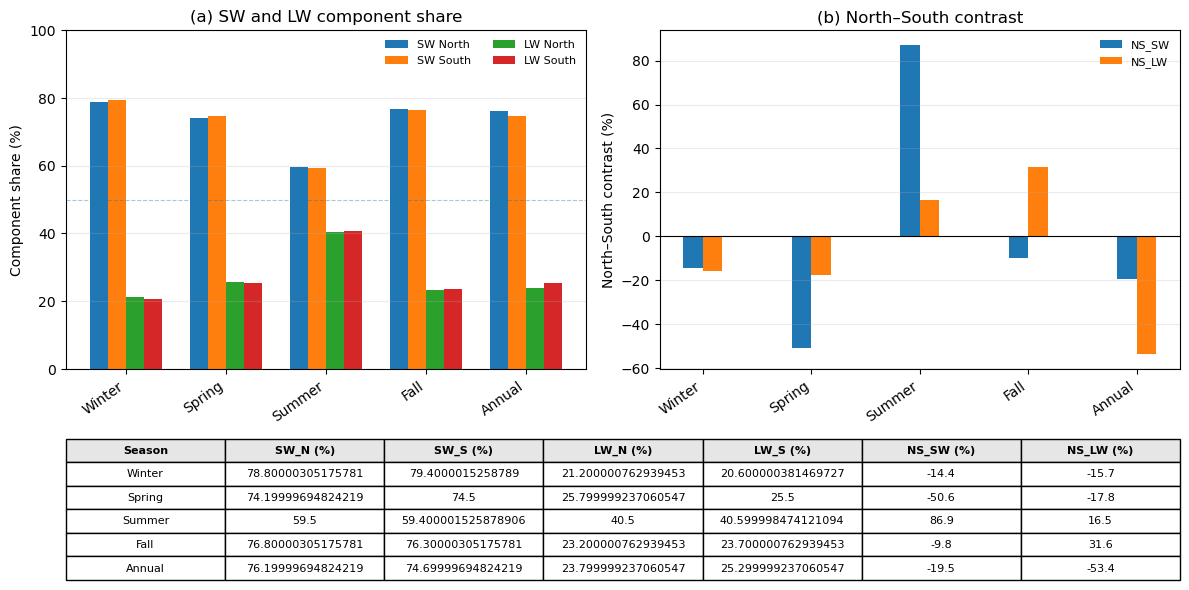

,Season,SW_N (%),SW_S (%),LW_N (%),LW_S (%),NS_SW (%),NS_LW (%)
0,Winter,78.800003,79.400002,21.200001,20.600000,-14.4,-15.7
1,Spring,74.199997,74.500000,25.799999,25.500000,-50.6,-17.8
2,Summer,59.500000,59.400002,40.500000,40.599998,86.9,16.5
3,Fall,76.800003,76.300003,23.200001,23.700001,-9.8,31.6
4,Annual,76.199997,74.699997,23.799999,25.299999,-19.5,-53.4


In [5]:
# radiation_component_share_NS_contrast_plot_with_table
# Run this directly after the main polar + boxplot cell

import pandas as pd

component_share = {
    "ΔSWnet": {"North": [], "South": []},
    "ΔLWnet": {"North": [], "South": []},
}

ns_contrast = {
    "ΔSWnet": [],
    "ΔLWnet": [],
}

for season in seasons_plot:
    mons = season_months[season]
    tmask = np.isin(months, mons)

    mean_sw_3d = np.nanmean(vars_3d["swnet"][tmask, :], axis=0)
    mean_sw_pp = np.nanmean(vars_pp["swnet"][tmask, :], axis=0)

    mean_lw_3d = np.nanmean(vars_3d["lwnet"][tmask, :], axis=0)
    mean_lw_pp = np.nanmean(vars_pp["lwnet"][tmask, :], axis=0)

    dsw_grid = make_diff_grid(mean_sw_3d, mean_sw_pp)
    dlw_grid = make_diff_grid(mean_lw_3d, mean_lw_pp)

    denom = np.abs(dsw_grid) + np.abs(dlw_grid)

    pct_sw = np.where(denom > 1e-6, np.abs(dsw_grid) / denom * 100.0, np.nan)
    pct_lw = np.where(denom > 1e-6, np.abs(dlw_grid) / denom * 100.0, np.nan)

    valid = (
        np.isfinite(dsw_grid) &
        np.isfinite(dlw_grid) &
        np.isfinite(aspect_deg_grid) &
        np.isfinite(slope_deg_grid) &
        slope_mask
    )

    north = valid & north_mask
    south = valid & south_mask

    component_share["ΔSWnet"]["North"].append(np.nanmedian(pct_sw[north]))
    component_share["ΔSWnet"]["South"].append(np.nanmedian(pct_sw[south]))

    component_share["ΔLWnet"]["North"].append(np.nanmedian(pct_lw[north]))
    component_share["ΔLWnet"]["South"].append(np.nanmedian(pct_lw[south]))

    sw_n = np.nanmedian(dsw_grid[north])
    sw_s = np.nanmedian(dsw_grid[south])
    lw_n = np.nanmedian(dlw_grid[north])
    lw_s = np.nanmedian(dlw_grid[south])

    ns_sw = np.where(
        (np.abs(sw_s) + np.abs(sw_n)) > 1e-6,
        ((sw_s - sw_n) / (np.abs(sw_s) + np.abs(sw_n))) * 100.0,
        np.nan
    )

    ns_lw = np.where(
        (np.abs(lw_s) + np.abs(lw_n)) > 1e-6,
        ((lw_s - lw_n) / (np.abs(lw_s) + np.abs(lw_n))) * 100.0,
        np.nan
    )

    ns_contrast["ΔSWnet"].append(float(ns_sw))
    ns_contrast["ΔLWnet"].append(float(ns_lw))

table_rows = []

for j, season in enumerate(seasons_plot):
    table_rows.append({
        "Season": season,
        "SW_N (%)": component_share["ΔSWnet"]["North"][j],
        "SW_S (%)": component_share["ΔSWnet"]["South"][j],
        "LW_N (%)": component_share["ΔLWnet"]["North"][j],
        "LW_S (%)": component_share["ΔLWnet"]["South"][j],
        "NS_SW (%)": ns_contrast["ΔSWnet"][j],
        "NS_LW (%)": ns_contrast["ΔLWnet"][j],
    })

df_component = pd.DataFrame(table_rows)
dfp = df_component.round(1).copy()

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.2])

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax_table = fig.add_subplot(gs[1, :])
ax_table.axis("off")

x = np.arange(len(dfp["Season"]))
w = 0.18

ax0.bar(x - 1.5*w, dfp["SW_N (%)"], width=w, label="SW North")
ax0.bar(x - 0.5*w, dfp["SW_S (%)"], width=w, label="SW South")
ax0.bar(x + 0.5*w, dfp["LW_N (%)"], width=w, label="LW North")
ax0.bar(x + 1.5*w, dfp["LW_S (%)"], width=w, label="LW South")

ax0.axhline(50, linestyle="--", linewidth=0.8, alpha=0.4)
ax0.set_xticks(x)
ax0.set_xticklabels(dfp["Season"], rotation=35, ha="right")
ax0.set_ylabel("Component share (%)")
ax0.set_title("(a) SW and LW component share")
ax0.set_ylim(0, 100)
ax0.grid(True, axis="y", alpha=0.25)
ax0.legend(frameon=False, fontsize=8, ncol=2)

ax1.bar(x - w/2, dfp["NS_SW (%)"], width=w, label="NS_SW")
ax1.bar(x + w/2, dfp["NS_LW (%)"], width=w, label="NS_LW")

ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(dfp["Season"], rotation=35, ha="right")
ax1.set_ylabel("North–South contrast (%)")
ax1.set_title("(b) North–South contrast")
ax1.grid(True, axis="y", alpha=0.25)
ax1.legend(frameon=False, fontsize=8)

table_cols = ["Season", "SW_N (%)", "SW_S (%)", "LW_N (%)", "LW_S (%)", "NS_SW (%)", "NS_LW (%)"]
table_vals = dfp[table_cols].values

tbl = ax_table.table(
    cellText=table_vals,
    colLabels=table_cols,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.25)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("0.9")

plt.tight_layout()

plt.savefig(
    os.path.join(outputdir, "radiation_component_share_NS_contrast_plot_with_table.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

display(dfp)

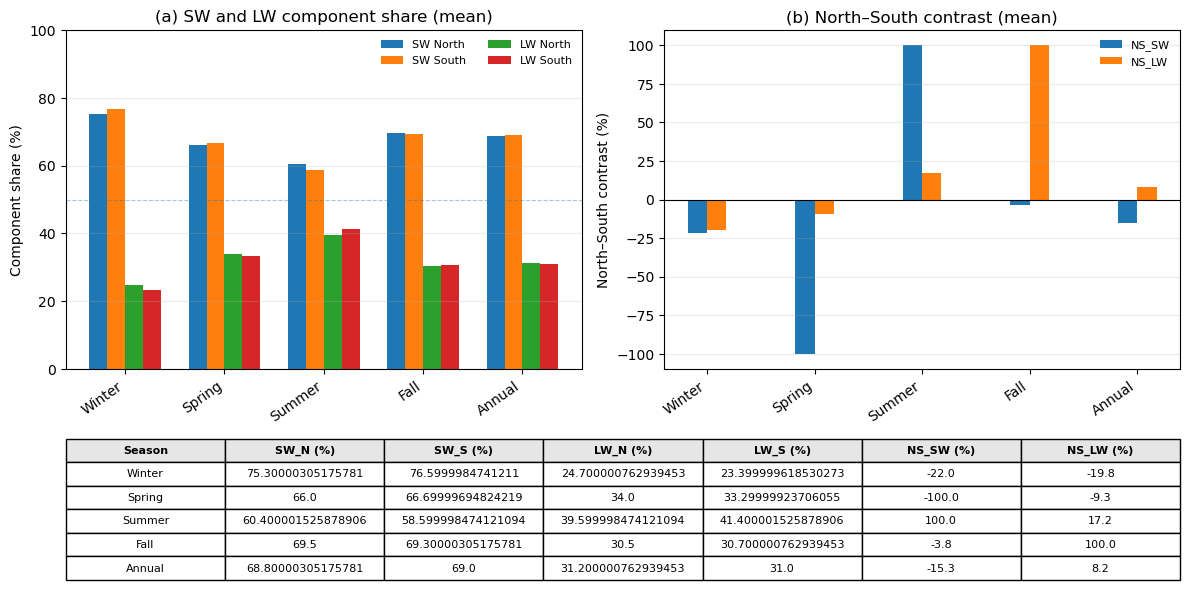

,Season,SW_N (%),SW_S (%),LW_N (%),LW_S (%),NS_SW (%),NS_LW (%)
0,Winter,75.300003,76.599998,24.700001,23.400000,-22.0,-19.8
1,Spring,66.000000,66.699997,34.000000,33.299999,-100.0,-9.3
2,Summer,60.400002,58.599998,39.599998,41.400002,100.0,17.2
3,Fall,69.500000,69.300003,30.500000,30.700001,-3.8,100.0
4,Annual,68.800003,69.000000,31.200001,31.000000,-15.3,8.2


In [6]:
# radiation_component_share_NS_contrast_plot_with_table (MEAN VERSION)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

component_share = {
    "ΔSWnet": {"North": [], "South": []},
    "ΔLWnet": {"North": [], "South": []},
}

ns_contrast = {
    "ΔSWnet": [],
    "ΔLWnet": [],
}

for season in seasons_plot:
    mons = season_months[season]
    tmask = np.isin(months, mons)

    # seasonal means (time → hru)
    mean_sw_3d = np.nanmean(vars_3d["swnet"][tmask, :], axis=0)
    mean_sw_pp = np.nanmean(vars_pp["swnet"][tmask, :], axis=0)

    mean_lw_3d = np.nanmean(vars_3d["lwnet"][tmask, :], axis=0)
    mean_lw_pp = np.nanmean(vars_pp["lwnet"][tmask, :], axis=0)

    # map to grid
    dsw_grid = make_diff_grid(mean_sw_3d, mean_sw_pp)
    dlw_grid = make_diff_grid(mean_lw_3d, mean_lw_pp)

    # component share (per grid cell)
    denom = np.abs(dsw_grid) + np.abs(dlw_grid)

    pct_sw = np.where(
        denom > 1e-6,
        np.abs(dsw_grid) / denom * 100.0,
        np.nan
    )

    pct_lw = np.where(
        denom > 1e-6,
        np.abs(dlw_grid) / denom * 100.0,
        np.nan
    )

    # valid mask
    valid = (
        np.isfinite(dsw_grid) &
        np.isfinite(dlw_grid) &
        np.isfinite(aspect_deg_grid) &
        np.isfinite(slope_deg_grid) &
        slope_mask
    )

    north = valid & north_mask
    south = valid & south_mask

    # --------- USE MEAN HERE ----------
    component_share["ΔSWnet"]["North"].append(np.nanmean(pct_sw[north]))
    component_share["ΔSWnet"]["South"].append(np.nanmean(pct_sw[south]))

    component_share["ΔLWnet"]["North"].append(np.nanmean(pct_lw[north]))
    component_share["ΔLWnet"]["South"].append(np.nanmean(pct_lw[south]))

    # mean values for NS contrast
    sw_n = np.nanmean(dsw_grid[north])
    sw_s = np.nanmean(dsw_grid[south])
    lw_n = np.nanmean(dlw_grid[north])
    lw_s = np.nanmean(dlw_grid[south])

    # NS contrast
    ns_sw = np.where(
        (np.abs(sw_s) + np.abs(sw_n)) > 1e-6,
        ((sw_s - sw_n) / (np.abs(sw_s) + np.abs(sw_n))) * 100.0,
        np.nan
    )

    ns_lw = np.where(
        (np.abs(lw_s) + np.abs(lw_n)) > 1e-6,
        ((lw_s - lw_n) / (np.abs(lw_s) + np.abs(lw_n))) * 100.0,
        np.nan
    )

    ns_contrast["ΔSWnet"].append(float(ns_sw))
    ns_contrast["ΔLWnet"].append(float(ns_lw))

# --------- TABLE ---------

table_rows = []

for j, season in enumerate(seasons_plot):
    table_rows.append({
        "Season": season,
        "SW_N (%)": component_share["ΔSWnet"]["North"][j],
        "SW_S (%)": component_share["ΔSWnet"]["South"][j],
        "LW_N (%)": component_share["ΔLWnet"]["North"][j],
        "LW_S (%)": component_share["ΔLWnet"]["South"][j],
        "NS_SW (%)": ns_contrast["ΔSWnet"][j],
        "NS_LW (%)": ns_contrast["ΔLWnet"][j],
    })

df_component = pd.DataFrame(table_rows)
dfp = df_component.round(1).copy()

# --------- PLOT ---------

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.2])

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax_table = fig.add_subplot(gs[1, :])
ax_table.axis("off")

x = np.arange(len(dfp["Season"]))
w = 0.18

# (a) Component share
ax0.bar(x - 1.5*w, dfp["SW_N (%)"], width=w, label="SW North")
ax0.bar(x - 0.5*w, dfp["SW_S (%)"], width=w, label="SW South")
ax0.bar(x + 0.5*w, dfp["LW_N (%)"], width=w, label="LW North")
ax0.bar(x + 1.5*w, dfp["LW_S (%)"], width=w, label="LW South")

ax0.axhline(50, linestyle="--", linewidth=0.8, alpha=0.4)
ax0.set_xticks(x)
ax0.set_xticklabels(dfp["Season"], rotation=35, ha="right")
ax0.set_ylabel("Component share (%)")
ax0.set_title("(a) SW and LW component share (mean)")
ax0.set_ylim(0, 100)
ax0.grid(True, axis="y", alpha=0.25)
ax0.legend(frameon=False, fontsize=8, ncol=2)

# (b) NS contrast
ax1.bar(x - w/2, dfp["NS_SW (%)"], width=w, label="NS_SW")
ax1.bar(x + w/2, dfp["NS_LW (%)"], width=w, label="NS_LW")

ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(dfp["Season"], rotation=35, ha="right")
ax1.set_ylabel("North–South contrast (%)")
ax1.set_title("(b) North–South contrast (mean)")
ax1.grid(True, axis="y", alpha=0.25)
ax1.legend(frameon=False, fontsize=8)

# table
table_cols = ["Season", "SW_N (%)", "SW_S (%)", "LW_N (%)", "LW_S (%)", "NS_SW (%)", "NS_LW (%)"]
table_vals = dfp[table_cols].values

tbl = ax_table.table(
    cellText=table_vals,
    colLabels=table_cols,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.25)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("0.9")

plt.tight_layout()

plt.savefig(
    os.path.join(outputdir, "radiation_component_share_NS_contrast_MEAN.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

display(dfp)

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/729150838.py:141: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.where(np.isfinite(aspect_deg_grid), np.mod(aspect_deg_grid, 360.0), np.nan)        # solves warning issue if aspect has NaN


same HRU grid: False
same CID grid: True
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swdn_3d', 'swnet', 'lwdn', 'lwdn_3d', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swnet', 'lwdn', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
Processing: Winter
Processing: Spring
Processing: Summer
Processing: Fall
Processing: Annual


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/3836961574.py:88: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(


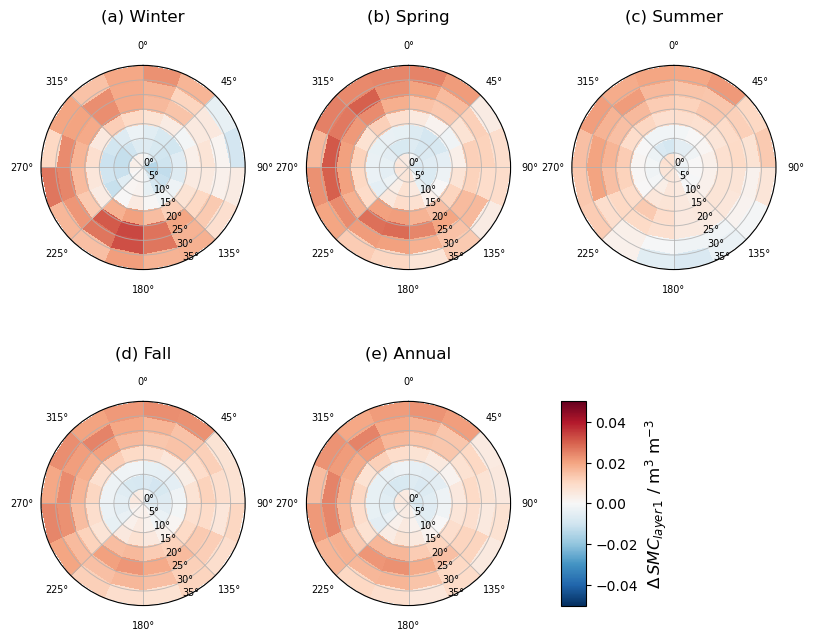

Winter: min=-0.0158, max=0.0335, mean=0.0059
Spring: min=-0.0087, max=0.0312, mean=0.0084
Summer: min=-0.0087, max=0.0217, mean=0.0062
Fall: min=-0.0090, max=0.0249, mean=0.0074
Annual: min=-0.0084, max=0.0248, mean=0.0070


In [19]:
print("3D:", path_3d)
print("PP:", path_pp)

# load mapping + terrain
hrus_3d, cids_3d, tmp_3d, hrus_pp, cids_pp, tmp_pp, slope_deg_grid, aspect_deg_grid = \
    load_mapping_and_terrain(path_pp, path_3d, buffer)

# read variable
vars_3d = read_hru_vars(path_3d, ["smc"])
vars_pp = read_hru_vars(path_pp, ["smc"])

# first soil layer
# smc shape: time x hru x soil
smc_3d = vars_3d["smc"][:, :, 0]
smc_pp = vars_pp["smc"][:, :, 0]

# time → months
months = np.array(times.dt.month)

season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
    "Annual": list(range(1, 13)),
}

# bins
slope_edges = np.arange(0, 40, 5)
aspect_edges = np.arange(0, 360, 22.5)

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
Theta, R = np.meshgrid(theta_edges, slope_edges)

# build seasonal polar
polar_means = {}
polar_counts = {}

for season, mons in season_months.items():

    print("Processing:", season)

    tmask = np.isin(months, mons)

    mean_3d = np.nanmean(smc_3d[tmask, :], axis=0)
    mean_pp = np.nanmean(smc_pp[tmask, :], axis=0)

    pm, pc = build_polar_from_grid_diff(
        mean_3d, mean_pp,
        hrus_3d, cids_3d, tmp_3d,
        hrus_pp, cids_pp, tmp_pp,
        slope_deg_grid, aspect_deg_grid,
        slope_edges, aspect_edges,
        buffer
    )

    polar_means[season] = pm
    polar_counts[season] = pc

# plot
fig = plt.figure(figsize=(10, 8), facecolor="white")

positions = [1, 2, 3, 4, 5]
seasons_plot = ["Winter", "Spring", "Summer", "Fall", "Annual"]

titles = [
    r"(a) Winter",
    r"(b) Spring",
    r"(c) Summer",
    r"(d) Fall",
    r"(e) Annual",
]

# use fixed scale for SMC difference
norm = colors.TwoSlopeNorm(vmin=-0.05, vcenter=0.0, vmax=0.05)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

axes_list = []
pcm = None

for idx, season, title in zip(positions, seasons_plot, titles):

    ax = fig.add_subplot(2, 3, idx, projection="polar")
    axes_list.append(ax)

    pcm = ax.pcolormesh(
        Theta, R, polar_means[season],
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 35)
    ax.set_rticks(np.arange(0, 36, 5))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 36, 5)], fontsize=7)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(
        np.arange(0, 360, 45),
        labels=[f"{a}°" for a in np.arange(0, 360, 45)],
        fontsize=7
    )

    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.set_title(title, fontsize=12, pad=14)

plt.subplots_adjust(wspace=0.30, hspace=0.20, right=0.86)

# colorbar beside Annual
last_ax = axes_list[-1]
bbox = last_ax.get_position()

cax = fig.add_axes([
    bbox.x1 + 0.05,
    bbox.y0,
    0.025,
    bbox.height
])

cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label(r"$\Delta\,SMC_{layer\,1}$ / m$^3$ m$^{-3}$", fontsize=12)

plt.savefig(
    os.path.join(outputdir, "polar_seasonal_annual_diff_SMC_layer1_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

for season in seasons_plot:
    vals = polar_means[season]
    vals = vals[np.isfinite(vals)]
    print(f"{season}: min={np.nanmin(vals):.4f}, max={np.nanmax(vals):.4f}, mean={np.nanmean(vals):.4f}")

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/729150838.py:141: RuntimeWarning: invalid value encountered in remainder
  aspect_deg_grid = np.where(np.isfinite(aspect_deg_grid), np.mod(aspect_deg_grid, 360.0), np.nan)        # solves warning issue if aspect has NaN


same HRU grid: False
same CID grid: True
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swdn_3d', 'swnet', 'lwdn', 'lwdn_3d', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
Variables: ['qsnow', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swnet', 'lwdn', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']
3D totsmc shape: (8744, 1000)
PP totsmc shape: (8744, 1000)
Processing: Winter
Processing: Spring
Processing: Summer
Processing: Fall
Processing: Annual


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_365867/1858320186.py:90: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax.pcolormesh(


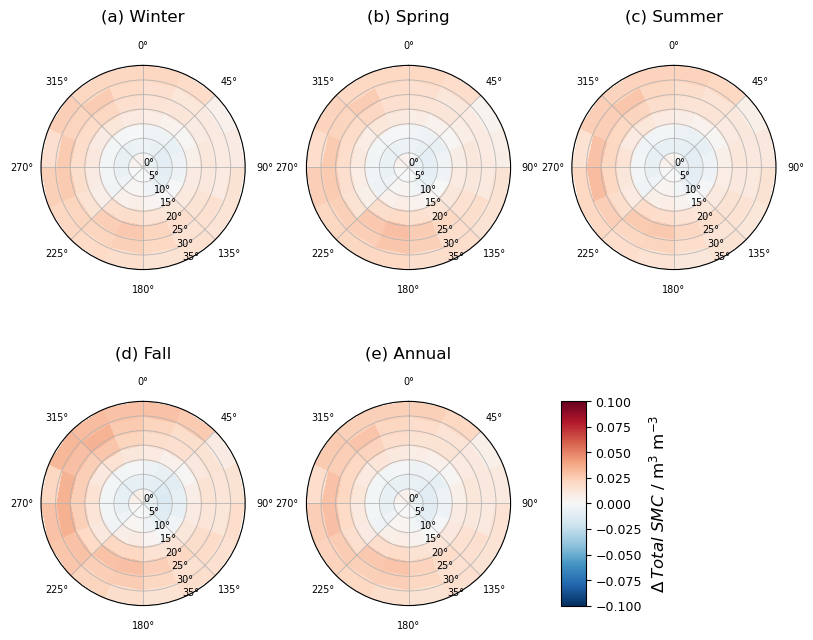

Winter: min=-0.0105, max=0.0266, mean=0.0076
Spring: min=-0.0099, max=0.0298, mean=0.0081
Summer: min=-0.0109, max=0.0307, mean=0.0079
Fall: min=-0.0141, max=0.0354, mean=0.0095
Annual: min=-0.0113, max=0.0297, mean=0.0083


In [20]:
print("3D:", path_3d)
print("PP:", path_pp)

# load mapping + terrain
hrus_3d, cids_3d, tmp_3d, hrus_pp, cids_pp, tmp_pp, slope_deg_grid, aspect_deg_grid = \
    load_mapping_and_terrain(path_pp, path_3d, buffer)

# read total soil moisture
vars_3d = read_hru_vars(path_3d, ["totsmc"])
vars_pp = read_hru_vars(path_pp, ["totsmc"])

print("3D totsmc shape:", vars_3d["totsmc"].shape)
print("PP totsmc shape:", vars_pp["totsmc"].shape)

# time x hru
smc_3d = vars_3d["totsmc"]
smc_pp = vars_pp["totsmc"]

# time → months
months = np.array(times.dt.month)

season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
    "Annual": list(range(1, 13)),
}

# bins
slope_edges = np.arange(0, 40, 5)
aspect_edges = np.arange(0, 360, 22.5)

theta_edges = np.deg2rad(np.append(aspect_edges, 360.0))
Theta, R = np.meshgrid(theta_edges, slope_edges)

# build seasonal polar
polar_means = {}
polar_counts = {}

for season, mons in season_months.items():

    print("Processing:", season)

    tmask = np.isin(months, mons)

    mean_3d = np.nanmean(smc_3d[tmask, :], axis=0)
    mean_pp = np.nanmean(smc_pp[tmask, :], axis=0)

    pm, pc = build_polar_from_grid_diff(
        mean_3d, mean_pp,
        hrus_3d, cids_3d, tmp_3d,
        hrus_pp, cids_pp, tmp_pp,
        slope_deg_grid, aspect_deg_grid,
        slope_edges, aspect_edges,
        buffer
    )

    polar_means[season] = pm
    polar_counts[season] = pc

# plot
fig = plt.figure(figsize=(10, 8), facecolor="white")

positions = [1, 2, 3, 4, 5]
seasons_plot = ["Winter", "Spring", "Summer", "Fall", "Annual"]

titles = [
    r"(a) Winter",
    r"(b) Spring",
    r"(c) Summer",
    r"(d) Fall",
    r"(e) Annual",
]

# adjust if your printed min/max show a wider or narrower range
norm = colors.TwoSlopeNorm(vmin=-0.10, vcenter=0.0, vmax=0.10)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")

axes_list = []
pcm = None

for idx, season, title in zip(positions, seasons_plot, titles):

    ax = fig.add_subplot(2, 3, idx, projection="polar")
    axes_list.append(ax)

    pcm = ax.pcolormesh(
        Theta,
        R,
        polar_means[season],
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 35)
    ax.set_rticks(np.arange(0, 36, 5))
    ax.set_yticklabels([f"{r}°" for r in np.arange(0, 36, 5)], fontsize=7)
    ax.set_rlabel_position(157.5)

    ax.set_thetagrids(
        np.arange(0, 360, 45),
        labels=[f"{a}°" for a in np.arange(0, 360, 45)],
        fontsize=7
    )

    ax.grid(True, linewidth=0.7, alpha=0.8)
    ax.set_title(title, fontsize=12, pad=14)

plt.subplots_adjust(wspace=0.30, hspace=0.20, right=0.86)

# colorbar beside Annual
last_ax = axes_list[-1]
bbox = last_ax.get_position()

cax = fig.add_axes([
    bbox.x1 + 0.05,
    bbox.y0,
    0.025,
    bbox.height
])

cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label(r"$\Delta\,Total\ SMC$ / m$^3$ m$^{-3}$", fontsize=12)
cbar.ax.tick_params(labelsize=9)

plt.savefig(
    os.path.join(outputdir, "polar_seasonal_annual_diff_TotalSMC_3D_minus_PP.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

for season in seasons_plot:
    vals = polar_means[season]
    vals = vals[np.isfinite(vals)]
    print(f"{season}: min={np.nanmin(vals):.4f}, max={np.nanmax(vals):.4f}, mean={np.nanmean(vals):.4f}")